In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look clean
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# Unziping the uploaded .zip file
import zipfile

with zipfile.ZipFile("archive.zip", "r") as z:
    z.extractall()

# Confirm what files we now have
import os
print(os.listdir())

['.config', 'archive.zip', 'E Commerce Dataset.xlsx', 'sample_data']


In [3]:
# Loading the dataset
df = pd.read_excel("E Commerce Dataset.xlsx", sheet_name="E Comm")

# Show the size and first rows
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (5630, 20)


,CustomerID,Churn,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
0,50001,1,4.0,Mobile Phone,3,6.0,Debit Card,Female,3.0,3,Laptop & Accessory,2,Single,9,1,11.0,1.0,1.0,5.0,159.93
1,50002,1,NaN,Phone,1,8.0,UPI,Male,3.0,4,Mobile,3,Single,7,1,15.0,0.0,1.0,0.0,120.90
2,50003,1,NaN,Phone,1,30.0,Debit Card,Male,2.0,4,Mobile,3,Single,6,1,14.0,0.0,1.0,3.0,120.28
3,50004,1,0.0,Phone,3,15.0,Debit Card,Male,2.0,4,Laptop & Accessory,5,Single,8,0,23.0,0.0,1.0,3.0,134.07
4,50005,1,0.0,Phone,1,12.0,CC,Male,NaN,3,Mobile,5,Single,3,0,11.0,1.0,1.0,3.0,129.60


In [4]:
# Overview of columns, types, and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Churn                        5630 non-null   int64  
 2   Tenure                       5366 non-null   float64
 3   PreferredLoginDevice         5630 non-null   object 
 4   CityTier                     5630 non-null   int64  
 5   WarehouseToHome              5379 non-null   float64
 6   PreferredPaymentMode         5630 non-null   object 
 7   Gender                       5630 non-null   object 
 8   HourSpendOnApp               5375 non-null   float64
 9   NumberOfDeviceRegistered     5630 non-null   int64  
 10  PreferedOrderCat             5630 non-null   object 
 11  SatisfactionScore            5630 non-null   int64  
 12  MaritalStatus                5630 non-null   object 
 13  NumberOfAddress   

Churn
0    4682
1     948
Name: count, dtype: int64

Churn rate: 16.8 %


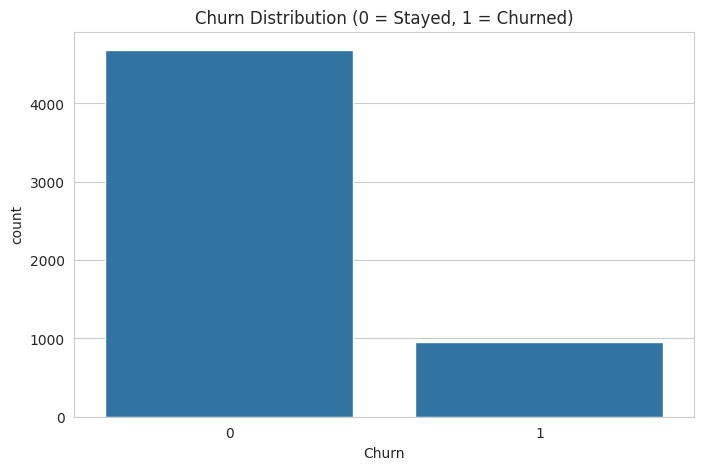

In [5]:
# How many customers churned vs stayed
print(df['Churn'].value_counts())
print()
print("Churn rate:", round(df['Churn'].mean() * 100, 1), "%")

# Visualization
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution (0 = Stayed, 1 = Churned)")
plt.show()

In [6]:
# Count missing values per column
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
print(missing)

Columns with missing values:
DaySinceLastOrder              307
OrderAmountHikeFromlastYear    265
Tenure                         264
OrderCount                     258
CouponUsed                     256
HourSpendOnApp                 255
WarehouseToHome                251
dtype: int64


In [7]:
# Summary statistics for numeric columns
df.describe()

,CustomerID,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount
count,5630.000000,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000
mean,52815.500000,0.168384,10.189899,1.654707,15.639896,2.931535,3.688988,3.066785,4.214032,0.284902,15.707922,1.751023,3.008004,4.543491,177.223030
std,1625.385339,0.374240,8.557241,0.915389,8.531475,0.721926,1.023999,1.380194,2.583586,0.451408,3.675485,1.894621,2.939680,3.654433,49.207036
min,50001.000000,0.000000,0.000000,1.000000,5.000000,0.000000,1.000000,1.000000,1.000000,0.000000,11.000000,0.000000,1.000000,0.000000,0.000000
25%,51408.250000,0.000000,2.000000,1.000000,9.000000,2.000000,3.000000,2.000000,2.000000,0.000000,13.000000,1.000000,1.000000,2.000000,145.770000
50%,52815.500000,0.000000,9.000000,1.000000,14.000000,3.000000,4.000000,3.000000,3.000000,0.000000,15.000000,1.000000,2.000000,3.000000,163.280000
75%,54222.750000,0.000000,16.000000,3.000000,20.000000,3.000000,4.000000,4.000000,6.000000,1.000000,18.000000,2.000000,3.000000,7.000000,196.392500
max,55630.000000,1.000000,61.000000,3.000000,127.000000,5.000000,6.000000,5.000000,22.000000,1.000000,26.000000,16.000000,16.000000,46.000000,324.990000


In [8]:
# Look at the unique values in each text column
for col in df.select_dtypes(include='object').columns:
    print(col, "->", df[col].unique())
    print()

PreferredLoginDevice -> ['Mobile Phone' 'Phone' 'Computer']

PreferredPaymentMode -> ['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Gender -> ['Female' 'Male']

PreferedOrderCat -> ['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']

MaritalStatus -> ['Single' 'Divorced' 'Married']



In [9]:
# Working on a copy so the original df stays intact
data = df.copy()
print("Working copy created. Shape:", data.shape)
# If cleaning goes wrong, df is still pristine

Working copy created. Shape: (5630, 20)


In [10]:
# Standardizing inconsistent category labels
data['PreferredLoginDevice'] = data['PreferredLoginDevice'].replace({'Phone': 'Mobile Phone'})

data['PreferredPaymentMode'] = data['PreferredPaymentMode'].replace({'CC': 'Credit Card', 'COD': 'Cash on Delivery'})

data['PreferedOrderCat'] = data['PreferedOrderCat'].replace({'Mobile': 'Mobile Phone'})

# Confirming everything is working fine
for col in ['PreferredLoginDevice', 'PreferredPaymentMode', 'PreferedOrderCat']:
    print(col, "->", data[col].unique())
    # .replace() swaps values according to the {old: new} dictionary. After this, each real category has exactly one name, so the model won't split one group into two.

PreferredLoginDevice -> ['Mobile Phone' 'Computer']
PreferredPaymentMode -> ['Debit Card' 'UPI' 'Credit Card' 'Cash on Delivery' 'E wallet']
PreferedOrderCat -> ['Laptop & Accessory' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


In [11]:
# Columns with missing values (all numeric)
missing_cols = ['Tenure', 'WarehouseToHome', 'HourSpendOnApp',
                'OrderAmountHikeFromlastYear', 'CouponUsed',
                'OrderCount', 'DaySinceLastOrder']

# Fill each with that column's median
for col in missing_cols:
    data[col] = data[col].fillna(data[col].median())

# Confirm no missing values remain
print("Total missing values after filling:", data.isnull().sum().sum())
# I chose to fill the missing data instead of dropping the rows, and that's because I would be dropping around 5% of my dataset and that would throw away customers and shrink my dataset

Total missing values after filling: 0


In [12]:
# CustomerID is just an identifier - no predictive value, my predictive model wont need it and it wouldn't change any of my results
data = data.drop('CustomerID', axis=1)
print("Shape after dropping CustomerID:", data.shape)

Shape after dropping CustomerID: (5630, 19)


In [13]:
# checking the current state and making sure that everything ran smoothly
print("Is CustomerID still here?", 'CustomerID' in data.columns)
print("Current shape:", data.shape)

Is CustomerID still here? False
Current shape: (5630, 19)


In [14]:
# Categorical text columns to encode
cat_cols = ['PreferredLoginDevice', 'PreferredPaymentMode',
            'Gender', 'PreferedOrderCat', 'MaritalStatus']

# One-hot encode them
data = pd.get_dummies(data, columns=cat_cols, drop_first=True)

# Convert any True/False columns to 1/0
data = data.astype({col: 'int' for col in data.select_dtypes(include='bool').columns})

print("Shape after encoding:", data.shape)
data.head()

Shape after encoding: (5630, 26)


,Churn,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,...,PreferredPaymentMode_Debit Card,PreferredPaymentMode_E wallet,PreferredPaymentMode_UPI,Gender_Male,PreferedOrderCat_Grocery,PreferedOrderCat_Laptop & Accessory,PreferedOrderCat_Mobile Phone,PreferedOrderCat_Others,MaritalStatus_Married,MaritalStatus_Single
0,1,4.0,3,6.0,3.0,3,2,9,1,11.0,...,1,0,0,0,0,1,0,0,0,1
1,1,9.0,1,8.0,3.0,4,3,7,1,15.0,...,0,0,1,1,0,0,1,0,0,1
2,1,9.0,1,30.0,2.0,4,3,6,1,14.0,...,1,0,0,1,0,0,1,0,0,1
3,1,0.0,3,15.0,2.0,4,5,8,0,23.0,...,1,0,0,1,0,1,0,0,0,1
4,1,0.0,1,12.0,3.0,3,5,3,0,11.0,...,0,0,0,1,0,0,1,0,0,1


In [15]:
from sklearn.model_selection import train_test_split

# X = all input features, y = the thing we predict
X = data.drop('Churn', axis=1)
y = data['Churn']

# Split: 70% train, 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Churn rate in train:", round(y_train.mean()*100, 1), "%")
print("Churn rate in test:", round(y_test.mean()*100, 1), "%")

Training set: (3941, 25)
Test set: (1689, 25)
Churn rate in train: 16.8 %
Churn rate in test: 16.8 %


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit the scaler on TRAINING data only, then apply to both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling complete.")
print("Train shape:", X_train_scaled.shape, "| Test shape:", X_test_scaled.shape)

Scaling complete.
Train shape: (3941, 25) | Test shape: (1689, 25)


In [17]:
# Final results (Double checking all values) before starting with the models
# 1. No missing values anywhere
print("1. Missing values remaining:", data.isnull().sum().sum(), "(should be 0)")

# 2. CustomerID is gone
print("2. CustomerID removed:", 'CustomerID' not in data.columns, "(should be True)")

# 3. No text columns left (everything encoded to numbers)
text_cols = list(data.select_dtypes(include='object').columns)
print("3. Text columns remaining:", text_cols, "(should be empty [])")

# 4. Train/test split sizes
print("4. X_train:", X_train.shape, "| X_test:", X_test.shape)

# 5. Stratification held
print("5. Churn rate -> train:", round(y_train.mean()*100,1),
      "% | test:", round(y_test.mean()*100,1), "% (both ~16.8%)")

# 6. Scaled arrays exist and match
print("6. X_train_scaled:", X_train_scaled.shape, "| X_test_scaled:", X_test_scaled.shape)

# 7. Train features count matches scaled count
print("7. Feature counts match:", X_train.shape[1] == X_train_scaled.shape[1], "(should be True)")


1. Missing values remaining: 0 (should be 0)
2. CustomerID removed: True (should be True)
3. Text columns remaining: [] (should be empty [])
4. X_train: (3941, 25) | X_test: (1689, 25)
5. Churn rate -> train: 16.8 % | test: 16.8 % (both ~16.8%)
6. X_train_scaled: (3941, 25) | X_test_scaled: (1689, 25)
7. Feature counts match: True (should be True)


In [18]:
data.to_csv("cleaned_churn_data.csv", index=False)

In [19]:
from sklearn.linear_model import LogisticRegression

# Creating and training the first model (Logistic Regression)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [20]:
from sklearn.ensemble import RandomForestClassifier

# Creating and training the second model (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


In [21]:
# Logistic Regression predictions (use scaled test data)
y_pred_lr = log_reg.predict(X_test_scaled)

# Random Forest predictions (use unscaled test data)
y_pred_rf = rf.predict(X_test)

# Quick peek at the first 20 predictions vs actual
print("Actual:   ", list(y_test[:20]))
print("LR pred:  ", list(y_pred_lr[:20]))
print("RF pred:  ", list(y_pred_rf[:20]))

Actual:    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0]
LR pred:   [np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
RF pred:   [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [22]:
print("Actual:   ", list(y_test[:20]))
print("LR pred:  ", [int(x) for x in y_pred_lr[:20]])
print("RF pred:  ", [int(x) for x in y_pred_rf[:20]])

Actual:    [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0]
LR pred:   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0]
RF pred:   [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0]


In [23]:
# Probability of churn (the "1" class) - needed for ROC curve later
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print("Probabilities captured for both models.")
print("Example - first 5 churn probabilities (RF):", y_prob_rf[:5].round(3))

Probabilities captured for both models.
Example - first 5 churn probabilities (RF): [0.01 0.38 0.05 0.56 0.03]


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=== Logistic Regression ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")

print("\n=== Random Forest ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")

=== Logistic Regression ===
Accuracy:  0.8934
Precision: 0.7708
Recall:    0.5211
F1-Score:  0.6218

=== Random Forest ===
Accuracy:  0.9680
Precision: 0.9528
Recall:    0.8521
F1-Score:  0.8996


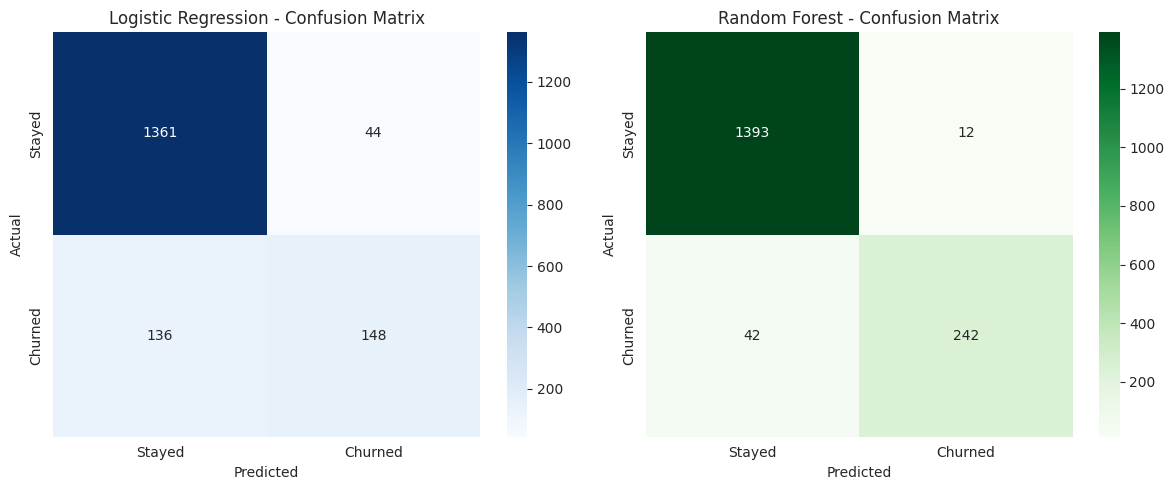

In [25]:
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
axes[0].set_title('Logistic Regression - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=200, bbox_inches='tight')
plt.show()

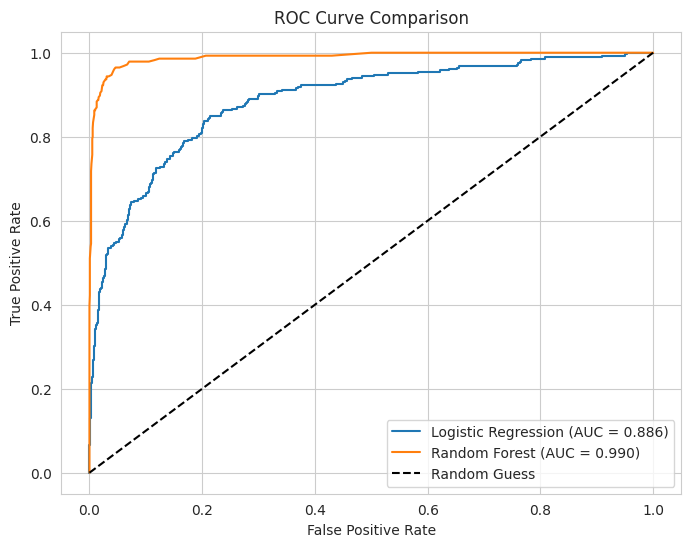

AUC - Logistic Regression: 0.8856
AUC - Random Forest:       0.9898


In [26]:
from sklearn.metrics import roc_curve, roc_auc_score

# Compute ROC for both
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

print(f"AUC - Logistic Regression: {auc_lr:.4f}")
print(f"AUC - Random Forest:       {auc_rf:.4f}")

Top 10 most important features for predicting churn:
                    Feature  Importance
                     Tenure    0.218501
             CashbackAmount    0.101264
            WarehouseToHome    0.078353
            NumberOfAddress    0.065280
                   Complain    0.064110
OrderAmountHikeFromlastYear    0.057049
          DaySinceLastOrder    0.056713
          SatisfactionScore    0.049230
   NumberOfDeviceRegistered    0.039347
                 OrderCount    0.032027


/tmp/ipykernel_803/836937263.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(10), x='Importance', y='Feature', palette='viridis')


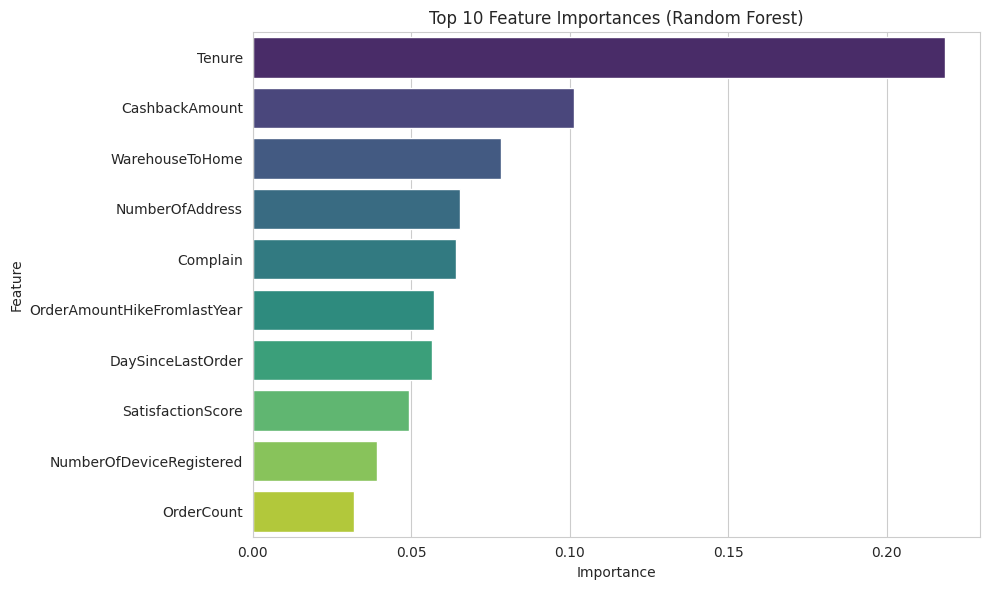

In [27]:
# Get feature importance from Random Forest
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Show top 10
print("Top 10 most important features for predicting churn:")
print(importance.head(10).to_string(index=False))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

In [28]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        auc_lr
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        auc_rf
    ]
}).round(4)

print(results.to_string(index=False))

   Metric  Logistic Regression  Random Forest
 Accuracy               0.8934         0.9680
Precision               0.7708         0.9528
   Recall               0.5211         0.8521
 F1-Score               0.6218         0.8996
      AUC               0.8856         0.9898


In [29]:
results.to_csv("model_results.csv", index=False)
importance.to_csv("feature_importance.csv", index=False)
print("Results saved.")

Results saved.


/tmp/ipykernel_803/1723647757.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance.head(10), x='Importance', y='Feature', palette='viridis')


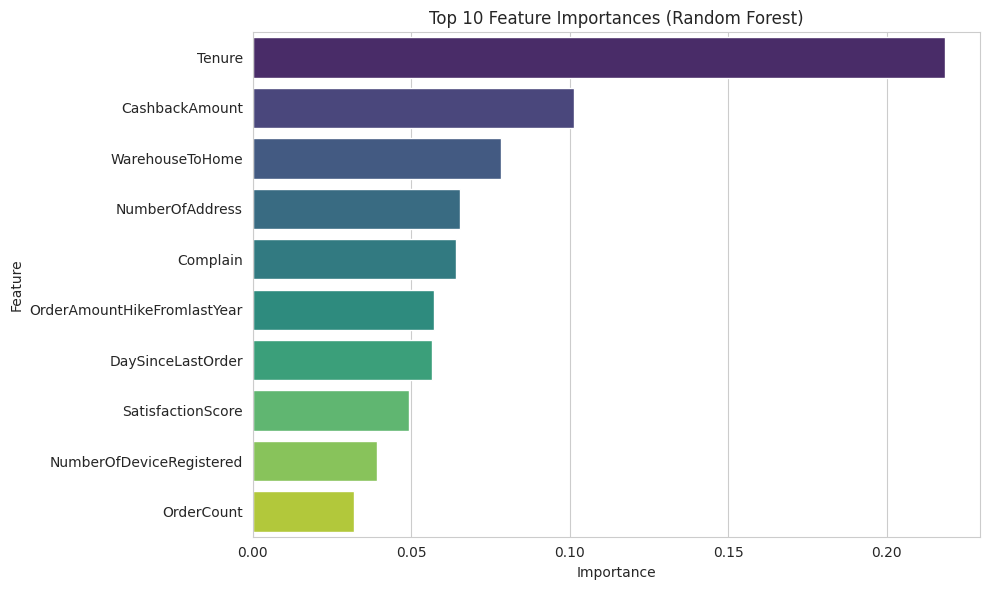

In [30]:
# Save confusion matrices, ROC, and feature importance as PNG files
# Re-run after each plot, or wrap each plot like this:
plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), x='Importance', y='Feature', palette='viridis')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()

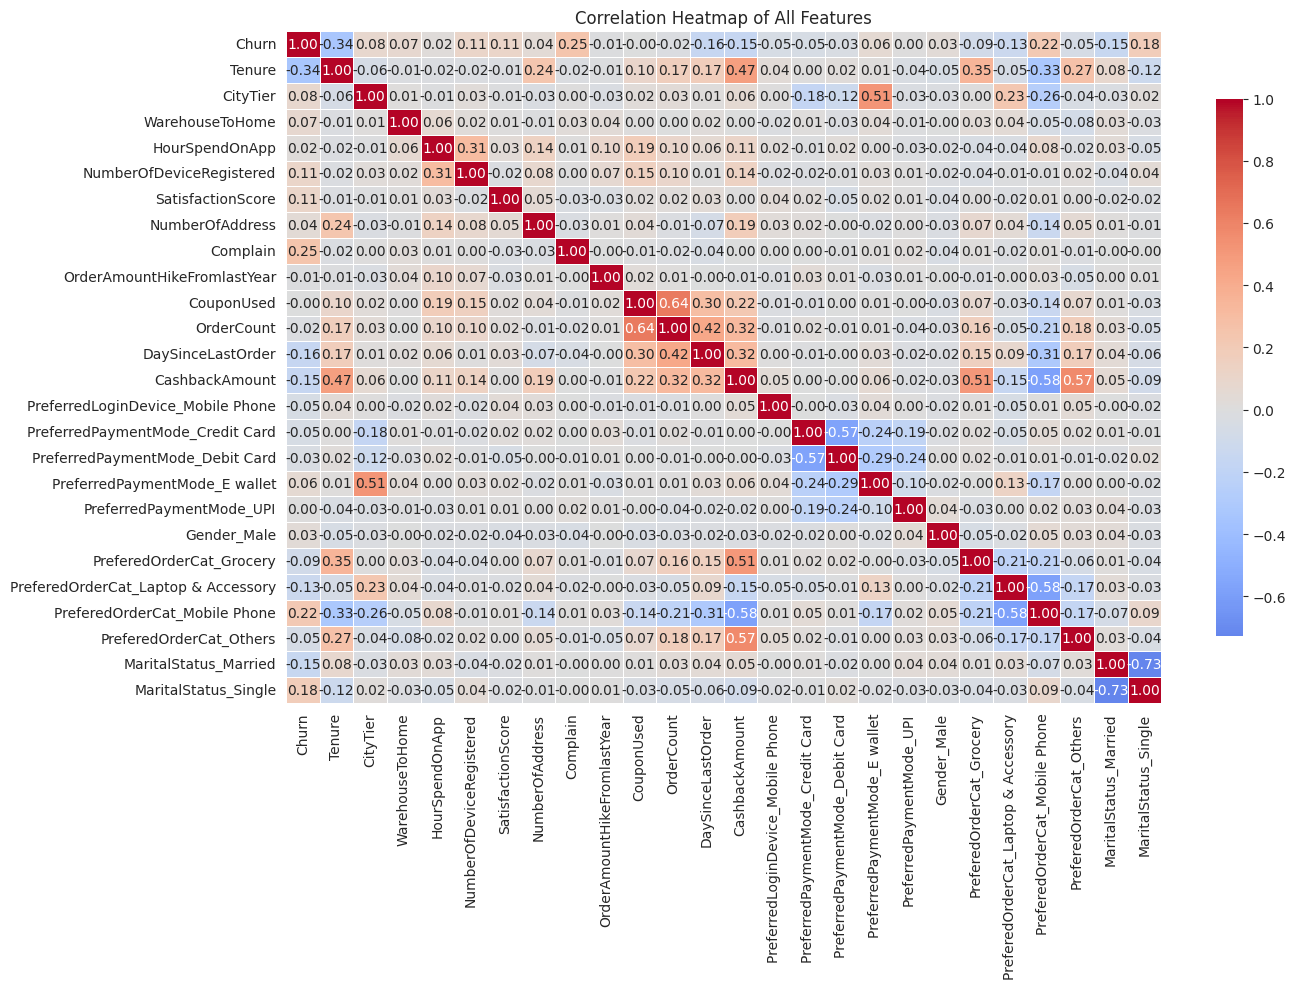

In [31]:
plt.figure(figsize=(14, 10))
correlation = data.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=False, linewidths=0.5,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of All Features')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=200, bbox_inches='tight')
plt.show()

In [32]:
from sklearn.cluster import KMeans

# Use the same feature set as the models, but WITHOUT the Churn label
# We're clustering customers based on their behavior, not their churn status
X_cluster = data.drop('Churn', axis=1)

# Scale for K-means (it's distance-based, so scaling matters - same reasoning as Logistic Regression)
from sklearn.preprocessing import StandardScaler
cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

print("Clustering data shape:", X_cluster_scaled.shape)

Clustering data shape: (5630, 25)


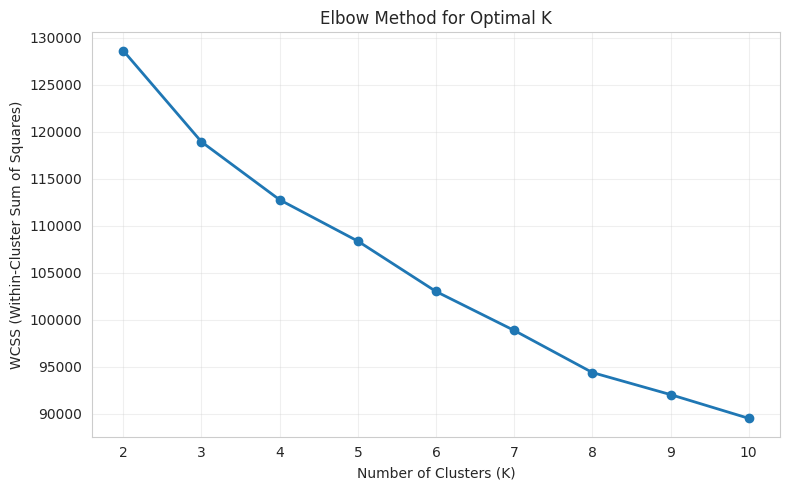

WCSS values: [128619.0, 118929.0, 112768.0, 108374.0, 103018.0, 98875.0, 94400.0, 92053.0, 89530.0]


In [33]:
# Try K from 2 to 10 and record the within-cluster sum of squares (WCSS / inertia)
wcss = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_cluster_scaled)
    wcss.append(km.inertia_)

# Plot the elbow
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=200, bbox_inches='tight')
plt.show()

print("WCSS values:", [round(w, 0) for w in wcss])

In [34]:
# Use the K you chose from the elbow plot
optimal_k = 4   # ← change this if your elbow suggests a different value

# Fit K-means
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

# Add cluster labels to a copy of the data so we can profile them
data_with_clusters = data.copy()
data_with_clusters['Cluster'] = clusters

# How big is each cluster?
print("Cluster sizes:")
print(data_with_clusters['Cluster'].value_counts().sort_index())

# Churn rate per cluster - this is the KEY result
print("\nChurn rate by cluster:")
print(data_with_clusters.groupby('Cluster')['Churn'].agg(['mean', 'count']).round(3))

Cluster sizes:
Cluster
0     264
1    2077
2     410
3    2879
Name: count, dtype: int64

Churn rate by cluster:
          mean  count
Cluster              
0        0.076    264
1        0.275   2077
2        0.049    410
3        0.117   2879


In [35]:
# Profile each cluster: the average of each feature per cluster
# Focus on the most interpretable features
profile_features = ['Tenure', 'SatisfactionScore', 'Complain', 'DaySinceLastOrder',
                    'OrderCount', 'CashbackAmount', 'WarehouseToHome', 'Churn']

cluster_profile = data_with_clusters.groupby('Cluster')[profile_features].mean().round(2)
print("Cluster Profiles (average values per cluster):")
print(cluster_profile)

Cluster Profiles (average values per cluster):
         Tenure  SatisfactionScore  Complain  DaySinceLastOrder  OrderCount  \
Cluster                                                                       
0         20.12               3.08      0.26               7.27        5.25   
1          6.56               3.08      0.30               2.96        2.15   
2         20.53               3.08      0.31               6.43        4.60   
3         10.31               3.06      0.28               5.01        3.10   

         CashbackAmount  WarehouseToHome  Churn  
Cluster                                          
0                304.56            12.74   0.08  
1                140.27            14.92   0.28  
2                266.23            16.56   0.05  
3                179.53            16.15   0.12  


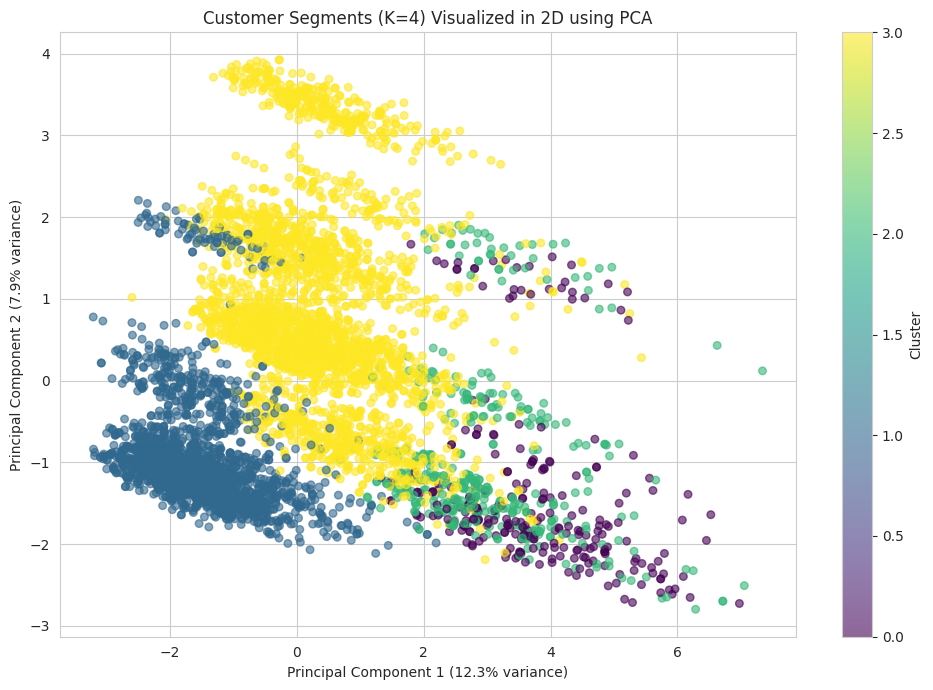


The 2 PCA components together explain 20.2% of the total variance in the data.


In [36]:
from sklearn.decomposition import PCA

# Compress to 2 dimensions for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_cluster_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                      cmap='viridis', alpha=0.6, s=30)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'Customer Segments (K={optimal_k}) Visualized in 2D using PCA')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nThe 2 PCA components together explain "
      f"{sum(pca.explained_variance_ratio_)*100:.1f}% of the total variance in the data.")

In [37]:
# Save the cluster profile table
cluster_profile.to_csv('cluster_profiles.csv')
print("Saved: cluster_profiles.csv")

# Save the cluster sizes and churn rates per cluster
cluster_summary = data_with_clusters.groupby('Cluster')['Churn'].agg(['mean', 'count']).round(3)
cluster_summary.columns = ['Churn_Rate', 'Customer_Count']
cluster_summary.to_csv('cluster_summary.csv')
print("Saved: cluster_summary.csv")

# Save the full data with cluster labels attached (very useful for the dashboard later)
data_with_clusters.to_csv('data_with_clusters.csv', index=False)
print("Saved: data_with_clusters.csv")

Saved: cluster_profiles.csv
Saved: cluster_summary.csv
Saved: data_with_clusters.csv


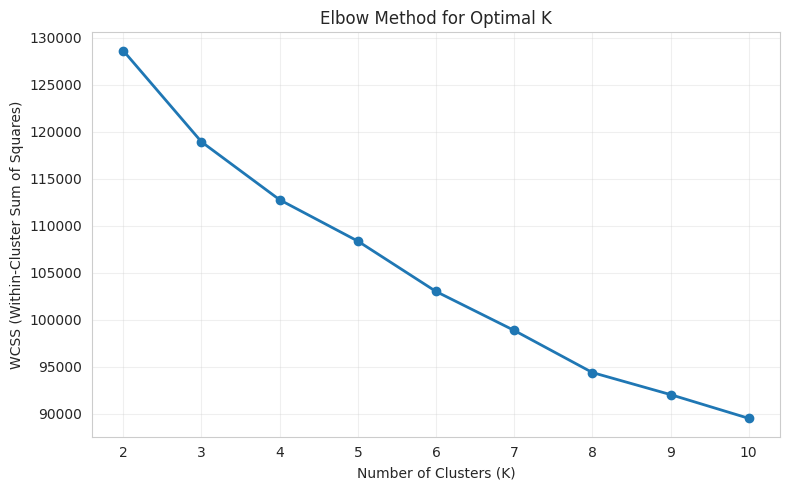

Saved: elbow_method.png


In [38]:
plt.figure(figsize=(8, 5))
plt.plot(list(k_range), wcss, marker='o', linewidth=2)
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('elbow_method.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: elbow_method.png")

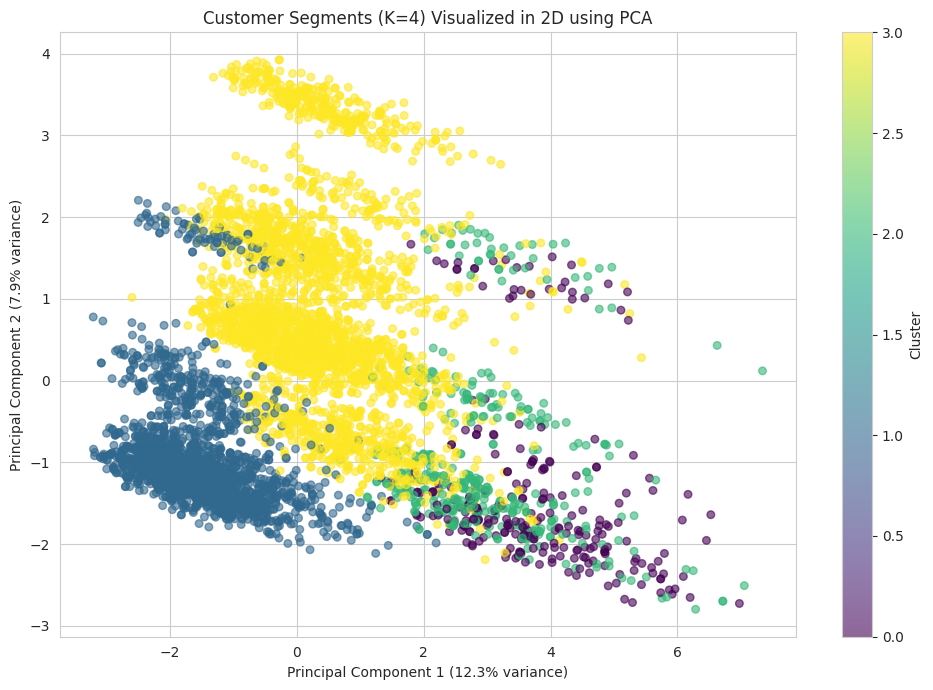

Saved: cluster_visualization.png


In [39]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters,
                      cmap='viridis', alpha=0.6, s=30)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'Customer Segments (K={optimal_k}) Visualized in 2D using PCA')
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.savefig('cluster_visualization.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: cluster_visualization.png")

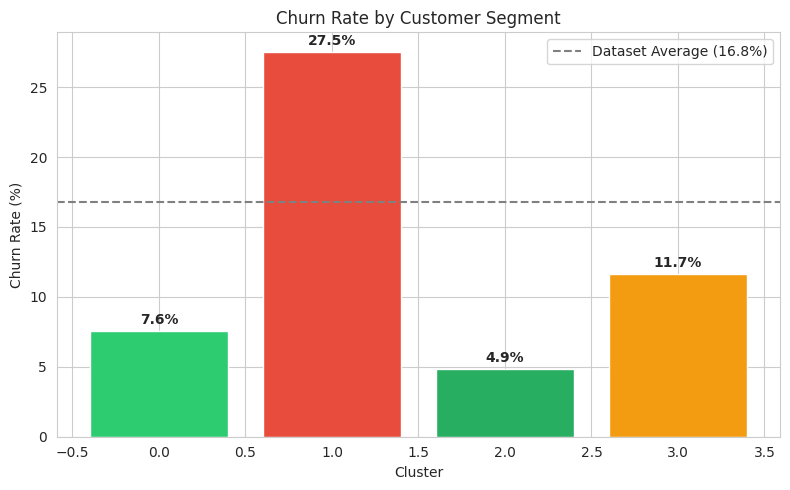

Saved: churn_by_cluster.png


In [40]:
plt.figure(figsize=(8, 5))
churn_per_cluster = data_with_clusters.groupby('Cluster')['Churn'].mean() * 100
bars = plt.bar(churn_per_cluster.index, churn_per_cluster.values,
               color=['#2ecc71', '#e74c3c', '#27ae60', '#f39c12'])
plt.xlabel('Cluster')
plt.ylabel('Churn Rate (%)')
plt.title('Churn Rate by Customer Segment')
plt.axhline(y=16.8, color='gray', linestyle='--', label='Dataset Average (16.8%)')
plt.legend()
# Add value labels on top of each bar
for bar, value in zip(bars, churn_per_cluster.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{value:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('churn_by_cluster.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: churn_by_cluster.png")